# Polymorph ordering under the Cacelli potential

MC under the Cacelli GBQIII potential settles at V/molecule ≈ 96.5 Å³, against an
experimental ≈ 116 Å³. Is that a sampling failure — the run never equilibrated — or is
96.5 genuinely where the model wants to be?

Neither, quite. MC is finding the potential's true minimum, but that minimum is the
**wrong crystal**: Cacelli prefers a slipped-parallel packing over the experimental
herringbone, and the preference *grows under compression*, inverting right around the
density the training data occupies. Everything below is static lattice-energy evaluation
on structures already on disk — no MC, no DFT.

The direction itself is not new. The project notes and Cacelli et al. (2004) both record
that herringbone is not GBQIII's ground state — their own run leaves it too (Table V:
96.8 Å³) — and the dimer-level cause was worked out earlier: slipped-parallel binds at
−36.6 meV against T-shaped at −26.8 meV, and herringbone lives on T-shaped contacts. What
is new here is the volume dependence, the density at which herringbone stops being
metastable, and the observation that the condensed-phase refit minimises at the training
density.

Worth keeping in view: in the ab initio truth the T-shaped and slipped-parallel dimers are
essentially degenerate (≈ −2.2 kcal/mol each), and the polymorph gap — about
0.23 kcal/mol per pair — sits *below* the dimer fit's own RMS of ~0.5 kcal/mol. Polymorph
selection in benzene is not resolvable at the pair level at all; it is a lattice effect.
That, rather than parity error, is the real argument for a many-body descriptor.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import ase.io
import numpy as np
from ase.db import connect
from scipy.optimize import minimize

from asmcmc.fitting_gbq.data import extract_periodic_pairs
from asmcmc.potentials import CACELLI_POTENTIAL, DEFAULT_POTENTIAL, calc_total_energy
from asmcmc.utils import coarse_grain_frame

# `asmcmc.fitting_gbq.plots` forces the Agg backend on import; keep the magic
# after all imports so figures still render inline.
%matplotlib inline
import matplotlib.pyplot as plt

EV_TO_KCAL = 23.060541945329334
CUTOFF = 20.0                       # lattice sums converged; GB decays as r^-6
CIF = "../data/benzene_pbca_cod_7238223.cif"
MCDB = "../results/validation/100.0_6.324209e-07/herringbone/simulation.db"

# Reference densities (A^3 per molecule)
V_MC = 96.5        # this MC production run; Cacelli Table V gives 96.8
V_EXPT = 116.0     # experiment, as quoted by Cacelli (cell 7.37, 9.34, 6.74)
V_TRAIN = 193.5    # the DFT training set -- a single value, every frame

## Structures

Two packings, both coarse-grained to one ellipsoid per molecule by
`asmcmc.utils.coarse_grain_frame`:

- **Herringbone** — the experimental Pbca crystal, `data/benzene_pbca_cod_7238223.cif`.
  This determination sits at 123.6 Å³/molecule, larger than the 116 Å³ Cacelli quotes;
  it is the same Pbca motif at a different temperature, and the scans cover both.
- **Slipped-parallel** — the final frame of the validated 100 K / 1 atm herringbone
  production run, which converted to slipped-parallel during equilibration.

`coarse_grain_frame` unwraps molecules across the periodic boundary before averaging.
That matters here: every Pbca molecule straddles a cell face, and a naive centroid puts
all four beads on the same point.

In [2]:
hb0 = coarse_grain_frame(ase.io.read(CIF))
with connect(MCDB) as db:
    row = db.get(id=[r.id for r in db.select()][-1])
sp0 = row.toatoms()
sp0.arrays["or_vec"] = np.asarray(row.data["or_vec"])


def contact_character(frame, cut=5.5):
    """Percentage of contact-shell pairs that are edge-to-face vs face-to-face."""
    p = extract_periodic_pairs(frame, "or_vec", cut)
    ang = np.degrees(np.arccos(np.clip(np.abs(p[:, 3]), 0, 1)))
    return 100 * (ang > 60).mean(), 100 * (ang < 30).mean(), len(ang)


for label, f in [("herringbone (Pbca)", hb0), ("slipped-parallel (MC)", sp0)]:
    e2f, f2f, npair = contact_character(f)
    print(f"{label:<24s} N={len(f):3d}  V/mol {f.get_volume()/len(f):6.2f}  "
          f"edge-to-face {e2f:5.1f}%  face-to-face {f2f:5.1f}%  ({npair} pairs)")

herringbone (Pbca)       N=  4  V/mol 123.58  edge-to-face 100.0%  face-to-face   0.0%  (16 pairs)
slipped-parallel (MC)    N=400  V/mol  96.55  edge-to-face  55.4%  face-to-face  44.1%  (3560 pairs)


Confirms the two are genuinely different packings, not the same structure at two
densities: Pbca is entirely edge-to-face at contact, the MC structure ~44%
face-to-face.

## Frozen-geometry E(V)

Scale each cell isotropically and evaluate the lattice energy. **Frozen geometry** —
cell *shape*, positions and orientations all held fixed, only volume changes. That is a
real limitation, addressed by the relaxation section below.

In [3]:
def scan_ev(frame, potential, volumes):
    """Lattice energy per molecule (kcal/mol) vs volume per molecule."""
    v0 = frame.get_volume() / len(frame)
    out = []
    for v in volumes:
        f = frame.copy()
        f.arrays["or_vec"] = frame.arrays["or_vec"].copy()
        f.set_cell(frame.cell * (v / v0) ** (1 / 3), scale_atoms=True)
        out.append(calc_total_energy(f, CUTOFF, potential) / len(f) * EV_TO_KCAL)
    return np.array(out)


vols = np.linspace(80.0, 200.0, 100)
curves = {f"{p}_{s}": scan_ev(fr, pot, vols)
          for p, pot in [("Cacelli", CACELLI_POTENTIAL), ("refit", DEFAULT_POTENTIAL)]
          for s, fr in [("HB", hb0), ("SP", sp0)]}

print(f"{'potential':<10} {'structure':<10} {'V_min':>8} {'E_min':>10}")
for key, e in curves.items():
    pot, struct = key.split("_")
    k = int(np.argmin(e))
    print(f"{pot:<10} {struct:<10} {vols[k]:8.1f} {e[k]:10.2f}")

potential  structure     V_min      E_min
Cacelli    HB            109.1      -9.58
Cacelli    SP             95.8     -10.87
refit      HB            200.0      -2.90
refit      SP            193.9      -3.16


Two things stand out.

**Cacelli binds slipped-parallel more strongly than herringbone** (−10.87 vs
−9.58 kcal/mol), and its slipped-parallel minimum, 95.8 Å³, lands almost exactly on the
MC production density of 96.5. The sampler is doing its job.

**The refit minimises at ≈ 200 Å³** — essentially the training set's single density of
193.5 — and is *unbound* (positive) at the experimental volume. About as direct a
demonstration as one could ask for that fitting at one density teaches a model that
density.

In [4]:
gap = curves["Cacelli_HB"] - curves["Cacelli_SP"]

print("E_herringbone - E_slipped-parallel  (negative = correct ordering)")
for v, lab in [(V_MC, "MC production"), (V_EXPT, "experiment"),
               (123.6, "the COD cif used here"), (V_TRAIN, "DFT training set")]:
    print(f"  {lab:<24s} V = {v:6.1f} A^3   {np.interp(v, vols, gap):+.2f} kcal/mol")
print(f"\n  sign change near V = {vols[np.argmin(np.abs(gap))]:.0f} A^3")

E_herringbone - E_slipped-parallel  (negative = correct ordering)
  MC production            V =   96.5 A^3   +2.26 kcal/mol
  experiment               V =  116.0 A^3   +0.18 kcal/mol
  the COD cif used here    V =  123.6 A^3   -0.14 kcal/mol
  DFT training set         V =  193.5 A^3   -0.46 kcal/mol

  sign change near V = 120 A^3


**The ordering error is volume-dependent, and it inverts right where the data lives.**
Cacelli ranks the polymorphs *correctly* at the training set's 193.5 Å³ and
*incorrectly* everywhere MC actually goes. A model validated only on parity against that
training set therefore cannot detect this failure — the failure is absent at the density
the training set occupies.

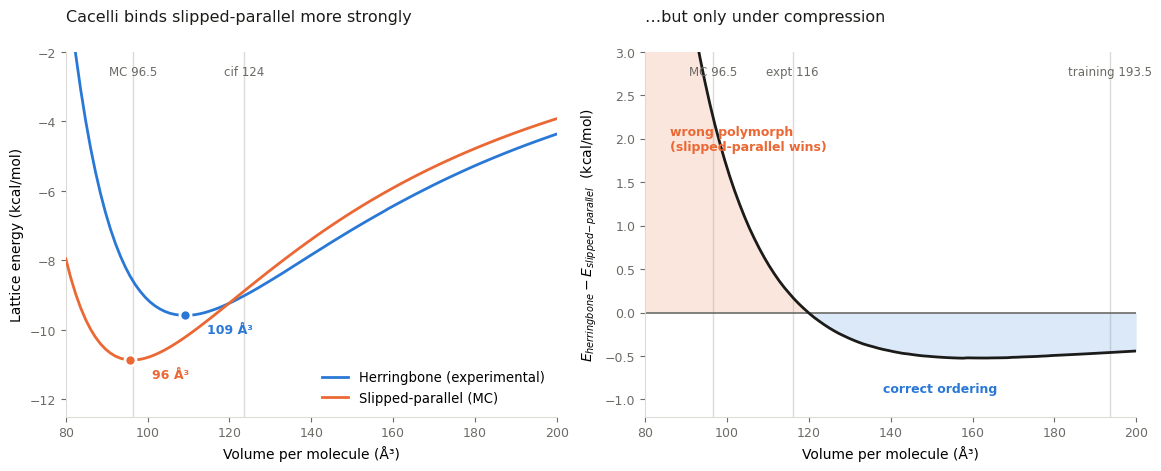

In [5]:
BLUE, ORANGE = "#2a78d6", "#eb6834"      # categorical slots 1-2, fixed order
INK, MUTED, GRID = "#1b1b19", "#6b6b66", "#dcdbd7"

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), constrained_layout=True)

ax = axes[0]
for x in (V_MC, 123.6):
    ax.axvline(x, color=GRID, lw=1, zorder=0)
for label, e, color in [("Herringbone (experimental)", curves["Cacelli_HB"], BLUE),
                        ("Slipped-parallel (MC)", curves["Cacelli_SP"], ORANGE)]:
    ax.plot(vols, e, lw=2, color=color, label=label, zorder=3)
    k = int(np.argmin(e))
    ax.plot(vols[k], e[k], "o", ms=8, color=color, mec="white", mew=2, zorder=4)
    ax.annotate(f"{vols[k]:.0f} Å³", (vols[k], e[k]), xytext=(16, -13),
                textcoords="offset points", ha="left", fontsize=9,
                color=color, fontweight="bold")
for x, lab in [(V_MC, "MC 96.5"), (123.6, "cif 124")]:
    ax.annotate(lab, (x, 1.0), xycoords=("data", "axes fraction"), xytext=(0, -10),
                textcoords="offset points", ha="center", va="top",
                fontsize=8.5, color=MUTED)
ax.set_ylabel("Lattice energy (kcal/mol)")
ax.set_title("Cacelli binds slipped-parallel more strongly", fontsize=11.5,
             color=INK, loc="left", pad=22)
ax.set_ylim(-12.5, -2)
ax.legend(frameon=False, loc="lower right", fontsize=9.5)

ax = axes[1]
ax.axhline(0, color=MUTED, lw=1.2, zorder=2)
ax.fill_between(vols, 0, gap, where=gap > 0, color=ORANGE, alpha=0.16, lw=0, zorder=1)
ax.fill_between(vols, 0, gap, where=gap <= 0, color=BLUE, alpha=0.16, lw=0, zorder=1)
ax.plot(vols, gap, lw=2, color=INK, zorder=3)
for x, lab in [(V_MC, "MC 96.5"), (V_EXPT, "expt 116"), (V_TRAIN, "training 193.5")]:
    ax.axvline(x, color=GRID, lw=1, zorder=0)
    ax.annotate(lab, (x, 1.0), xycoords=("data", "axes fraction"), xytext=(0, -10),
                textcoords="offset points", ha="center", va="top",
                fontsize=8.5, color=MUTED)
ax.annotate("wrong polymorph\n(slipped-parallel wins)", (86, 2.15), fontsize=9,
            color=ORANGE, fontweight="bold", va="top")
ax.annotate("correct ordering", (152, -0.92), fontsize=9, color=BLUE,
            fontweight="bold", ha="center")
ax.set_ylabel("$E_{herringbone} - E_{slipped\\!-\\!parallel}$  (kcal/mol)")
ax.set_title("…but only under compression", fontsize=11.5, color=INK, loc="left", pad=22)
ax.set_ylim(-1.2, 3.0)

for ax in axes:
    ax.set_xlabel("Volume per molecule (Å³)")
    ax.set_xlim(vols[0], vols[-1])
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=9)

fig.savefig("../results/validation/figures/step1_polymorph_ordering.png", dpi=200)
plt.show()

## Relaxation — is the frozen comparison fair?

The scans above are one-sided: the experimental Pbca geometry is optimal for *reality*,
not for Cacelli, so relaxing it can only lower its energy. If a relaxed herringbone
dropped below slipped-parallel, the ordering conclusion would collapse.

Two relaxations settle it, both over positions + orientations (disc normals as spherical
angles), minimised with Powell:

1. **Cell free** — does herringbone survive at all?
2. **Cell fixed**, scanned over volume — is herringbone a *local* minimum, and down to
   what density?

In [6]:
n = len(hb0)
u0 = hb0.arrays["or_vec"].copy()


def angles_to_vecs(a):
    t, p = a[:n], a[n:]
    return np.stack([np.sin(t) * np.cos(p), np.sin(t) * np.sin(p), np.cos(t)], axis=1)


def vecs_to_angles(u):
    u = u / np.linalg.norm(u, axis=1, keepdims=True)
    return np.concatenate([np.arccos(np.clip(u[:, 2], -1, 1)),
                           np.arctan2(u[:, 1], u[:, 0])])


def summarise(frame, label):
    """Energy plus the diagnostics that say whether it is still herringbone."""
    e2f, f2f, _ = contact_character(frame)
    e = calc_total_energy(frame, CUTOFF, CACELLI_POTENTIAL) / n * EV_TO_KCAL
    r_min = extract_periodic_pairs(frame, "or_vec", 12.0)[:, 0].min()
    # orientation memory: 1.0 means the disc normals never moved
    mem = np.abs(np.einsum("ij,ij->i", frame.arrays["or_vec"], u0)).mean()
    print(f"  {label:<28s} V/mol {frame.get_volume()/n:6.2f}  E {e:8.3f}  "
          f"r_min {r_min:5.2f}  e2f {e2f:5.1f}%  f2f {f2f:5.1f}%  |u.u0| {mem:.3f}")
    return e, e2f

In [7]:
# --- 1. cell free ---
def unpack_free(x):
    c = x[:6]
    f = hb0.copy()
    f.set_cell(np.array([[c[0], 0, 0], [c[1], c[2], 0], [c[3], c[4], c[5]]]))
    f.set_scaled_positions(x[6:6 + 3 * n].reshape(n, 3))
    f.arrays["or_vec"] = angles_to_vecs(x[6 + 3 * n:])
    return f


def energy_free(x):
    f = unpack_free(x)
    if abs(np.linalg.det(f.cell)) < 1e-3:
        return 1e6
    try:
        return calc_total_energy(f, CUTOFF, CACELLI_POTENTIAL) / n * EV_TO_KCAL
    except Exception:
        return 1e6


c0 = np.array(hb0.cell)
x0 = np.concatenate([[c0[0, 0], c0[1, 0], c0[1, 1], c0[2, 0], c0[2, 1], c0[2, 2]],
                     hb0.get_scaled_positions().ravel(), vecs_to_angles(u0)])

print("cell FREE")
summarise(hb0, "experimental start")
res = minimize(energy_free, x0, method="Powell",
               options={"maxiter": 40000, "maxfev": 200000, "xtol": 1e-6, "ftol": 1e-8})
e_free, _ = summarise(unpack_free(res.x), "relaxed (cell free)")

cell FREE
  experimental start           V/mol 123.58  E   -9.019  r_min  5.09  e2f 100.0%  f2f   0.0%  |u.u0| 1.000


  relaxed (cell free)          V/mol  92.80  E  -11.392  r_min  4.67  e2f  60.0%  f2f  40.0%  |u.u0| 0.963


**Herringbone does not survive a free relaxation.** It collapses to ≈ 93 Å³ and converts
to ~40% face-to-face contacts — the same character as the MC endpoint. Static
minimisation alone, with no Monte Carlo and no thermal sampling, reproduces the MC
result. That is independent confirmation that the sampler was never the problem.

The energy, −11.39 kcal/mol, is *below* the frozen slipped-parallel minimum of −10.87,
as expected: the MC structure is a 100 K thermal snapshot, not a relaxed one.

In [8]:
# --- 2. cell fixed, scanned over volume ---
print("cell FIXED (only positions + orientations relax)")
summarise(hb0, "experimental start")

relaxed = {}
for v_target in (96.5, 105.0, 110.0, V_EXPT):
    base = hb0.copy()
    base.arrays["or_vec"] = u0.copy()
    base.set_cell(hb0.cell * (v_target / (base.get_volume() / n)) ** (1 / 3),
                  scale_atoms=True)
    cell_fixed = base.cell.copy()

    def build(x, base=base, cell_fixed=cell_fixed):
        f = base.copy()
        f.set_cell(cell_fixed)
        f.set_scaled_positions(x[:3 * n].reshape(n, 3))
        f.arrays["or_vec"] = angles_to_vecs(x[3 * n:])
        return f

    def en(x, build=build):
        try:
            return calc_total_energy(build(x), CUTOFF, CACELLI_POTENTIAL) / n * EV_TO_KCAL
        except Exception:
            return 1e6

    xv = np.concatenate([base.get_scaled_positions().ravel(), vecs_to_angles(u0)])
    r = minimize(en, xv, method="Powell",
                 options={"maxiter": 40000, "maxfev": 120000, "xtol": 1e-7, "ftol": 1e-9})
    relaxed[v_target] = summarise(build(r.x), f"relaxed @ V={v_target:.1f} fixed")

cell FIXED (only positions + orientations relax)
  experimental start           V/mol 123.58  E   -9.019  r_min  5.09  e2f 100.0%  f2f   0.0%  |u.u0| 1.000


  relaxed @ V=96.5 fixed       V/mol  96.50  E  -10.303  r_min  4.69  e2f  50.0%  f2f  50.0%  |u.u0| 0.944


  relaxed @ V=105.0 fixed      V/mol 105.00  E  -10.261  r_min  4.82  e2f 100.0%  f2f   0.0%  |u.u0| 0.951


  relaxed @ V=110.0 fixed      V/mol 110.00  E  -10.014  r_min  4.90  e2f 100.0%  f2f   0.0%  |u.u0| 0.977


  relaxed @ V=116.0 fixed      V/mol 116.00  E   -9.639  r_min  4.99  e2f 100.0%  f2f   0.0%  |u.u0| 0.985


**Herringbone is a genuine local minimum — down to a limit.** At 105–116 Å³ the disc
normals barely move (|u·u₀| ≈ 0.95–0.99), contacts stay 100% edge-to-face, and the
minimum pair separation stays near 5 Å, so the free-cell collapse above was physics and
not a numerical pathology.

**At 96.5 Å³ it is gone**: contacts split 50/50 edge-to-face / face-to-face and the
structure has converted. So herringbone stops being even *metastable* somewhere between
96.5 and 105 Å³ — and MC's operating density, 96.5, sits on the far side of that limit.

So the defect is specific: the herringbone basin **exists but is too shallow**, and it is
**volume relaxation** that destroys it. That coupling to volume is exactly what NPT
samples and exactly what a fixed-density training set cannot see.

In [9]:
# Best *genuine* herringbone: only volumes where it stayed edge-to-face.
hb_true = {v: e for v, (e, e2f) in relaxed.items() if e2f > 95}
v_best = min(hb_true, key=hb_true.get)
print(f"best relaxed herringbone        {hb_true[v_best]:8.3f} kcal/mol  @ V = {v_best:.1f}")
print(f"fully relaxed (-> slipped-par.) {e_free:8.3f} kcal/mol")
print(f"\nGATE: deepen herringbone by {hb_true[v_best] - e_free:+.2f} kcal/mol relative to")
print( "      slipped-parallel, with the right volume dependence.")
print(f"\nmetastability limit: herringbone converts between 96.5 and "
      f"{min(hb_true):.0f} A^3 -- MC operates below it.")

best relaxed herringbone         -10.261 kcal/mol  @ V = 105.0
fully relaxed (-> slipped-par.)  -11.392 kcal/mol

GATE: deepen herringbone by +1.13 kcal/mol relative to
      slipped-parallel, with the right volume dependence.

metastability limit: herringbone converts between 96.5 and 105 A^3 -- MC operates below it.


## Findings

1. **MC was never at fault.** Static relaxation reproduces the MC endpoint
   independently. Cacelli's global minimum really is a slipped-parallel crystal near
   93–96 Å³.
2. **Herringbone is metastable, not absent** — a true local minimum at fixed volume
   between ~105 and 116 Å³. The correction must *deepen an existing basin*, not create a
   missing one. That is the easier of the two cases.
3. **But metastability is lost under compression**, somewhere between 96.5 and 105 Å³,
   and MC operates below that limit — so at MC's own density there is no herringbone
   basin left to stabilise.
4. **The failure is coupled to volume.** The frozen ordering error runs from
   +2.26 kcal/mol at 96.5 Å³ to −0.46 at 193.5 Å³, crossing zero near 120. A correction
   flat in density would shift both basins equally and change nothing.
5. **The training set cannot see any of this.** All 6,826 frames sit at 193.5 Å³ — the
   one density where Cacelli happens to rank the polymorphs correctly.
6. **The refit confirms the mechanism**, minimising at ≈200 Å³ and unbound at the
   experimental volume.

### Consequences

**A cheap new acceptance test.** Relaxed E(herringbone) < E(slipped-parallel), scored
statically — no MC run, no DFT. It belongs in `asmcmc/validation.py` beside
`dimer_benchmark`, and unlike the full MC validation protocol it can score a candidate in
seconds.

**A quantitative target:** ≈1.1 kcal/mol at the herringbone optimum, with the right volume
dependence — and enough curvature to restore metastability below 105 Å³.

**Check before any fitting:** can AniSOAP descriptors even *distinguish* these two
structures, and do they respond to density? If not, no fit built on them can move this
test, and the hyperparameters need revisiting first.

**A risk worth pricing early:** PBE-D3's own polymorph-ranking error is typically
~0.24 kcal/mol. Comfortably below 1.1, but worth confirming against benchmark data (X23)
before committing to a reference campaign — a model can only be as right as its reference.